In [ ]:
!pip install -q kagglehub
import kagglehub
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("1. Đang tải dữ liệu...")
dataset_path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")
train_dir = os.path.join(dataset_path, "Fast Food Classification V2/Train")
valid_dir = os.path.join(dataset_path, "Fast Food Classification V2/Valid")
test_dir = os.path.join(dataset_path, "Fast Food Classification V2/Test")

1. Đang tải dữ liệu...


100%|██████████| 821M/821M [00:06<00:00, 138MB/s]

Extracting files...


##  **BƯỚC 1: Chuẩn bị dữ liệu**

2. Đã chuẩn bị: Train(800), Valid(200), Test(200).
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s]


4. Bắt đầu huấn luyện và đánh giá (Mosaic) - Đã tối ưu hóa mượt mà...

Epoch [1/40] | Train Loss: 2.0132, Train Acc: 0.4925 | Valid Loss: 1.3317, Valid Acc: 0.5800
Epoch [2/40] | Train Loss: 1.0393, Train Acc: 0.8400 | Valid Loss: 0.9398, Valid Acc: 0.7000
Epoch [3/40] | Train Loss: 1.5420, Train Acc: 0.8762 | Valid Loss: 0.9612, Valid Acc: 0.7100
Epoch [4/40] | Train Loss: 1.0219, Train Acc: 0.9500 | Valid Loss: 0.9338, Valid Acc: 0.7150
Epoch [5/40] | Train Loss: 1.0093, Train Acc: 0.9650 | Valid Loss: 0.8984, Valid Acc: 0.7450
Epoch [6/40] | Train Loss: 0.8914, Train Acc: 0.9750 | Valid Loss: 0.8757, Valid Acc: 0.7200
Epoch [7/40] | Train Loss: 1.2578, Train Acc: 0.9825 | Valid Loss: 0.8984, Valid Acc: 0.7150
Epoch [8/40] | Train Loss: 0.5649, Train Acc: 0.9975 | Valid Loss: 0.7814, Valid Acc: 0.7500
Epoch [9/40] | Train Loss: 1.0089, Train Acc: 0.9825 | Valid Loss: 0.8546, Valid Acc: 0.7350
Epoch [10/40] | Train Loss: 1.1137, Train Acc: 0.9962 | Valid Loss: 0.8740, Valid Acc: 0.720

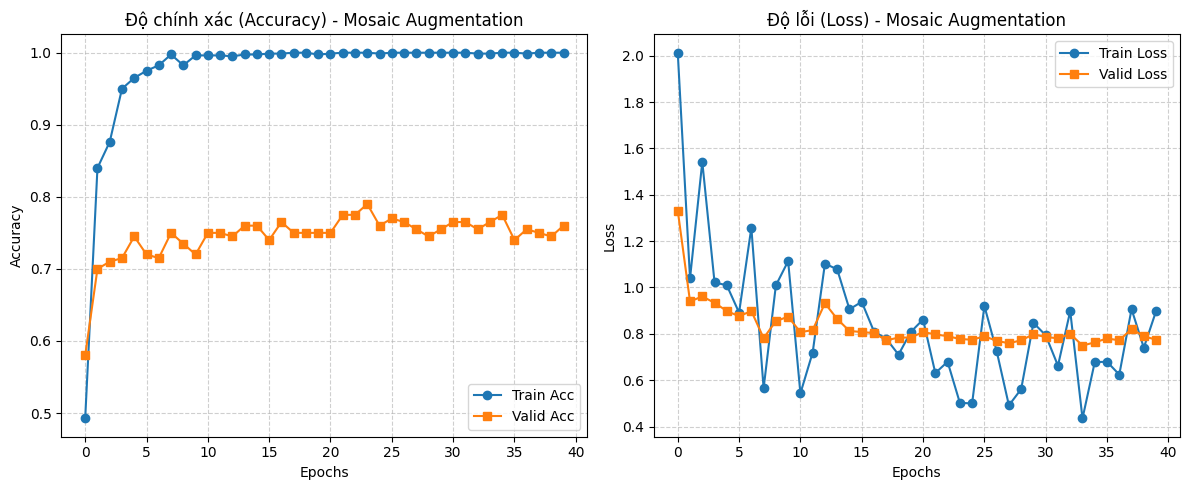

In [ ]:
from torchvision import transforms
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR


def apply_mosaic(inputs, targets, img_size=224):
    batch_size = inputs.size(0)
    idx0 = torch.arange(batch_size)
    idx1 = torch.randperm(batch_size)
    idx2 = torch.randperm(batch_size)
    idx3 = torch.randperm(batch_size)

    new_inputs = torch.zeros_like(inputs)
    c = img_size // 2

    new_inputs[:, :, 0:c, 0:c] = torch.nn.functional.interpolate(inputs[idx0], size=(c, c))
    new_inputs[:, :, 0:c, c:img_size] = torch.nn.functional.interpolate(inputs[idx1], size=(c, c))
    new_inputs[:, :, c:img_size, 0:c] = torch.nn.functional.interpolate(inputs[idx2], size=(c, c))
    new_inputs[:, :, c:img_size, c:img_size] = torch.nn.functional.interpolate(inputs[idx3], size=(c, c))

    return new_inputs, targets[idx0], targets[idx1], targets[idx2], targets[idx3]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train = datasets.ImageFolder(train_dir, transform=transform)
full_valid = datasets.ImageFolder(valid_dir, transform=transform)
full_test = datasets.ImageFolder(test_dir, transform=transform)

train_idx = torch.randperm(len(full_train))[:800]
valid_idx = torch.randperm(len(full_valid))[:200]
test_idx = torch.randperm(len(full_test))[:200]

train_loader = DataLoader(Subset(full_train, train_idx), batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(Subset(full_valid, valid_idx), batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(Subset(full_test, test_idx), batch_size=32, shuffle=False, num_workers=2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(full_train.classes))
model = model.to(device)
epochs = 40
mosaic_prob = 0.5
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)


train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        if np.random.rand() < mosaic_prob:
            inputs_m, t0, t1, t2, t3 = apply_mosaic(inputs, targets)
            outputs = model(inputs_m)

            loss = 0.25 * (criterion(outputs, t0) + criterion(outputs, t1) +
                           criterion(outputs, t2) + criterion(outputs, t3))
            _, predicted = outputs.max(1)
            correct_train += (predicted.eq(t0) | predicted.eq(t1) | predicted.eq(t2) | predicted.eq(t3)).sum().item()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, predicted = outputs.max(1)
            correct_train += predicted.eq(targets).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_train += targets.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_targets in valid_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)

            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_targets)

            val_loss += loss.item()
            _, predicted = val_outputs.max(1)
            total_val += val_targets.size(0)
            correct_val += predicted.eq(val_targets).sum().item()

    epoch_val_loss = val_loss / len(valid_loader)
    epoch_val_acc = correct_val / total_val
    valid_losses.append(epoch_val_loss)
    valid_accs.append(epoch_val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_val_loss:.4f}, Valid Acc: {epoch_val_acc:.4f}")
    torch.cuda.empty_cache()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(train_accs, label='Train Acc', color='tab:blue', marker='o')
ax1.plot(valid_accs, label='Valid Acc', color='tab:orange', marker='s')
ax1.set_title('Độ chính xác (Accuracy) - Mosaic Augmentation')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(train_losses, label='Train Loss', color='tab:blue', marker='o')
ax2.plot(valid_losses, label='Valid Loss', color='tab:orange', marker='s')
ax2.set_title('Độ lỗi (Loss) - Mosaic Augmentation')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Vẽ


Đang chạy dự đoán trên tập Test cho Phase 3 (Mosaic)...

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PHASE 3 (MOSAIC)
                precision    recall  f1-score   support

  Baked Potato       0.70      0.89      0.78        18
        Burger       0.92      0.77      0.84        31
Crispy Chicken       0.85      1.00      0.92        11
         Donut       0.89      0.80      0.84        20
         Fries       0.67      0.89      0.76        18
       Hot Dog       0.84      0.62      0.71        26
         Pizza       0.80      0.74      0.77        27
      Sandwich       0.77      0.87      0.82        23
          Taco       0.59      0.71      0.65        14
       Taquito       0.44      0.33      0.38        12

      accuracy                           0.77       200
     macro avg       0.75      0.76      0.75       200
  weighted avg       0.77      0.77      0.76       200



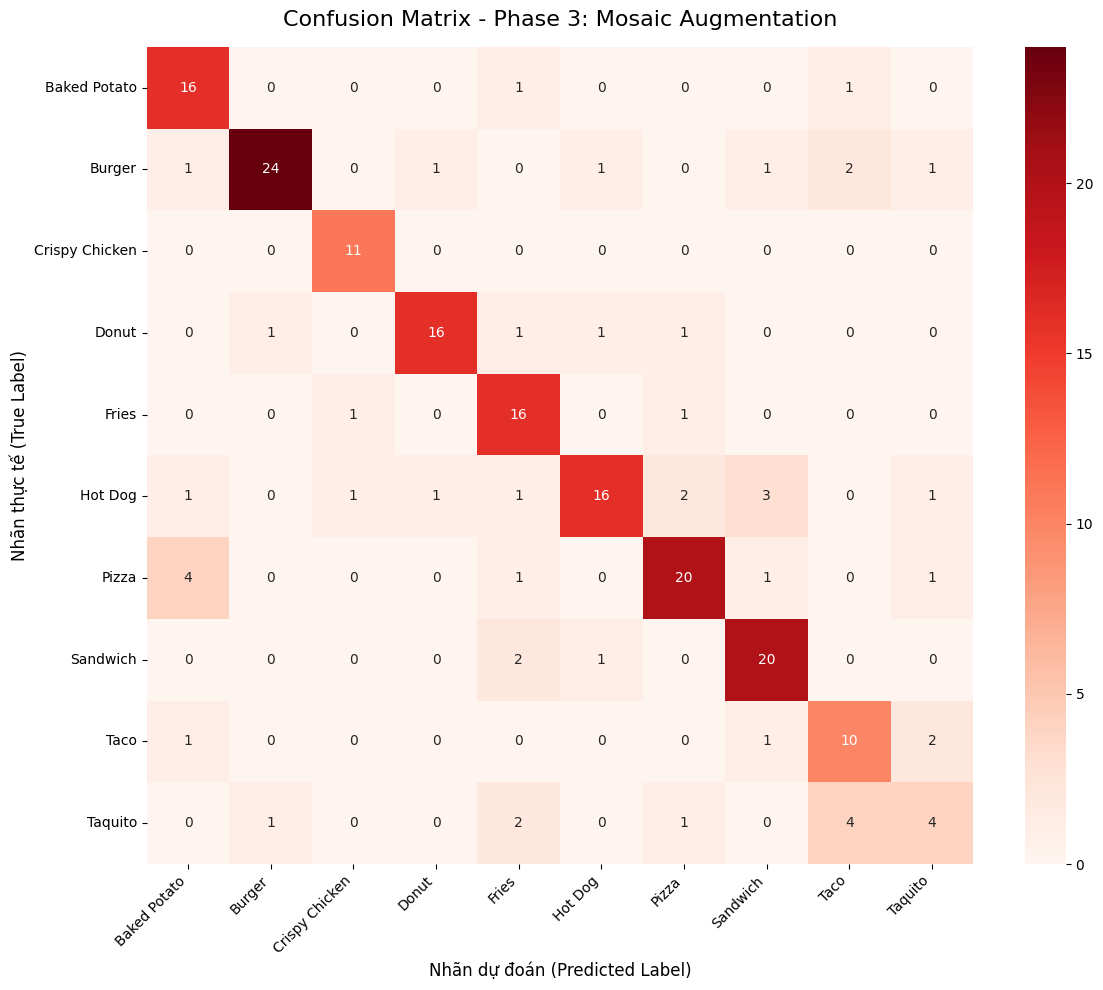

In [ ]:
print("\nĐang chạy dự đoán trên tập Test cho Phase 3 (Mosaic)...")

model.eval()

y_true_p3 = []
y_pred_p3 = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)
        _, predicted = torch.max(preds, 1)

        y_true_p3.extend(labels.cpu().numpy())
        y_pred_p3.extend(predicted.cpu().numpy())

class_names = full_test.classes

print("\n" + "="*60)
print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - PHASE 3 (MOSAIC)")
print("="*60)
print(classification_report(y_true_p3, y_pred_p3, target_names=class_names))

cm_p3 = confusion_matrix(y_true_p3, y_pred_p3)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_p3, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Phase 3: Mosaic Augmentation', fontsize=16, pad=15)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import torch

model_save_name = 'fastfood_resnet18_mosaic.pth'

torch.save(model.state_dict(), model_save_name)
print(f"Đã lưu trọng số vào file: {model_save_name}")

files.download(model_save_name)

Đã lưu trọng số vào file: fastfood_resnet18_mosaic.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>